# CIFAR-10 — Klasyfikacja + Adversarial Robustness

**Struktura notebooka**
1. Importy + Device
2. Dane i normalizacja
3. Definicje modeli
4. Funkcje pomocnicze
5. Trening standardowy (MLP, CNN, CNN_BETTER)
6. Adversarial Training (CNN_ROBUST)
7. Ewaluacja końcowa + Zapis modeli


## 1. Importy + Device

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, roc_auc_score


In [2]:
device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()          else "cpu"
)
print(f"Device: {device}")


Device: mps


## 2. Dane i normalizacja

Jedna spójna normalizacja (obliczona z danych) dla **wszystkich** modeli.


In [3]:
# Obliczamy mean i std na surowych pikselach [0, 1]
_tmp = DataLoader(
    torchvision.datasets.CIFAR10(root="./data", train=True,
                                 download=True, transform=transforms.ToTensor()),
    batch_size=512
)
_mean, _std, _n = torch.zeros(3), torch.zeros(3), 0
for imgs, _ in _tmp:
    _mean += imgs.mean(dim=[0, 2, 3])
    _std  += imgs.std(dim=[0, 2, 3])
    _n    += 1
MEAN = (_mean / _n).tolist()
STD  = (_std  / _n).tolist()
print(f'MEAN: {[f"{v:.4f}" for v in MEAN]}')
print(f'STD:  {[f"{v:.4f}" for v in STD]}')


MEAN: ['0.4914', '0.4822', '0.4466']
STD:  ['0.2470', '0.2434', '0.2615']


In [4]:
# Treningowy — z AutoAugment (CIFAR-10 policy)
transform_train = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Testowy — tylko normalizacja, bez augmentacji
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True,  download=False, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=0)
testloader  = DataLoader(testset,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train: {len(trainset)} | Test: {len(testset)}")

Train: 50000 | Test: 10000


## 3. Definicje modeli

### MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size: int, num_classes: int = 10, dropout_p: float = 0.2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(512, 256),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):         return self.layers(x)
    def predict_proba(self, x):   return torch.softmax(self(x), dim=1)
    def predict(self, x):         return torch.argmax(self.predict_proba(x), dim=1)


### CNN (mvp)

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.layers = nn.Sequential(
            # blok 1
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            # blok 2
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.2),
            # klasyfikator
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):         return self.layers(x)
    def predict_proba(self, x):   return torch.softmax(self(x), dim=1)
    def predict(self, x):         return torch.argmax(self.predict_proba(x), dim=1)


### CnnBetter (główny model do treningu i adversarial trainingu)

In [7]:
class CnnBetter(nn.Module):
    def __init__(self, num_classes: int = 10, dropout_p: float = 0.3):
        super().__init__()
        def block(in_c, out_c, drop):
            # Podwajamy kanały gdy zmniejszamy mapę o połowę — zachowujemy
            # całkowitą "pojemność informacyjną" warstwy (in_c * H * W ≈ out_c * H/2 * W/2)
            return [
                nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout(drop),
            ]
        self.layers = nn.Sequential(
            *block(3,  32,  dropout_p),   # kanały: 3→32,   mapa: 32×32→16×16
            *block(32, 64,  dropout_p),   # kanały: 32→64,  mapa: 16×16→8×8
            *block(64, 128, dropout_p),   # kanały: 64→128, mapa: 8×8→4×4
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):         return self.layers(x)
    def predict_proba(self, x):   return torch.softmax(self(x), dim=1)
    def predict(self, x):         return torch.argmax(self.predict_proba(x), dim=1)

### CnnAcc — Residual CNN (~93-95% accuracy)

Architektura z **residual connections** (skip connections):
- Wstępna konwolucja: 3→64
- 3 bloki residualne: 64 → 128 → 256 kanałów
- Global Average Pooling zamiast FC+Dropout
- Trening: Mixup α=0.4, CosineAnnealingLR, label_smoothing=0.1, 100 epok

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, stride=stride, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        # Projection shortcut — tylko gdy wymiary się zmieniają
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # <-- skip connection
        return self.relu(out)


class CnnAcc(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1  = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(64)
        self.relu   = nn.ReLU(inplace=True)

        self.layer1 = nn.Sequential(
            ResidualBlock(64,  64,  stride=1),
            ResidualBlock(64,  64,  stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64,  128, stride=2),
            ResidualBlock(128, 128, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x).view(x.size(0), -1)
        return self.fc(x)

    def predict_proba(self, x): return torch.softmax(self(x), dim=1)
    def predict(self, x):       return torch.argmax(self.predict_proba(x), dim=1)

## 4. Funkcje pomocnicze

In [9]:
def evaluate(model, loader):
    """Accuracy na czystych danych."""
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds_all.append(model.predict(images).cpu().numpy())
            labels_all.append(labels.cpu().numpy())
    return accuracy_score(np.concatenate(labels_all), np.concatenate(preds_all))


In [10]:
def evaluate_full(model, loader):
    """Zwraca (probs, preds, labels) — do liczenia Accuracy i AUROC."""
    model.eval()
    probs_all, preds_all, labels_all = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            probs_all.append(model.predict_proba(images).cpu().numpy())
            preds_all.append(model.predict(images).cpu().numpy())
            labels_all.append(labels.cpu().numpy())
    return (
        np.concatenate(probs_all),
        np.concatenate(preds_all),
        np.concatenate(labels_all),
    )


In [11]:
def evaluate_robust(model, loader, loss_fn, eps=8/255, n_batches=20):
    """
    Robust accuracy (PGD) na n_batches batchach.
    n_batches=None => cały loader (wolno!).
    """
    preds_all, labels_all = [], []
    for i, (images, labels) in enumerate(loader):
        if n_batches is not None and i >= n_batches:
            break
        images, labels = images.to(device), labels.to(device)
        adv = generate_pgd_attack(model, images, labels, loss_fn, eps=eps)
        with torch.no_grad():
            preds_all.append(model.predict(adv).cpu().numpy())
        labels_all.append(labels.cpu().numpy())
    return accuracy_score(np.concatenate(labels_all), np.concatenate(preds_all))


In [12]:
MODEL_REGISTRY = {
    "MLP":        (MLP,       {"input_size": 3 * 32 * 32}, "MLP_cifar10.pth"),
    "CNN":        (CNN,       {},                           "CNN_cifar10.pth"),
    "CNN_BETTER": (CnnBetter, {},                           "CNN_BETTER_cifar10.pth"),
    "CNN_ROBUST": (CnnBetter, {},                           "CNN_ROBUST_cifar10.pth"),
    "CNN_ACC":    (CnnAcc,    {},                           "CNN_ACC_cifar10.pth"),
}

def load_model(name: str) -> nn.Module:
    """Wczytuje model z pliku .pth na podstawie MODEL_REGISTRY."""
    ModelClass, kwargs, pth = MODEL_REGISTRY[name]
    m = ModelClass(**kwargs).to(device)
    m.load_state_dict(torch.load(pth, map_location=device, weights_only=True))
    m.eval()
    return m


In [13]:
def mixup_batch(x, y, alpha=0.4):
    """
    Mixup augmentacja: liniowa interpolacja między losowymi parami próbek.

    x_mixed = lam * x_i + (1-lam) * x_j,   lam ~ Beta(alpha, alpha)

    Returns:
        x_mixed : zmieszane obrazy
        y_a, y_b: oryginalne etykiety obu składników
        lam     : waga interpolacji
    """
    lam   = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

## 5. Trening standardowy

Trenujemy MLP, CNN (szybki, 20 epok) i CNN_BETTER (50 epok + scheduler).


In [14]:
def train(model, optimizer, loss_fn, num_epochs=20,
          train_loader=None, test_loader=None):
    """Prosty trening bez schedulera. Domyślnie używa globalnych loaderów."""
    if train_loader is None: train_loader = trainloader
    if test_loader  is None: test_loader  = testloader

    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss  = running_loss / len(train_loader)
        train_acc = evaluate(model, train_loader)
        test_acc  = evaluate(model, test_loader)
        print(f"Epoch {epoch+1:2d} | loss: {avg_loss:.4f} | "
              f"train: {train_acc:.2%} | test: {test_acc:.2%}")
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(avg_loss)

    return train_accs, test_accs, losses, model


In [15]:
def train_with_scheduler(model, optimizer, scheduler, loss_fn, num_epochs=50,
                         train_loader=None, test_loader=None):
    """Trening z ReduceLROnPlateau. Domyślnie używa globalnych loaderów."""
    if train_loader is None: train_loader = trainloader
    if test_loader  is None: test_loader  = testloader

    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss  = running_loss / len(train_loader)
        train_acc = evaluate(model, train_loader)
        test_acc  = evaluate(model, test_loader)
        scheduler.step(avg_loss)
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:2d} | loss: {avg_loss:.4f} | "
              f"train: {train_acc:.2%} | test: {test_acc:.2%} | lr: {lr:.2e}")
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(avg_loss)

    return train_accs, test_accs, losses, model


In [16]:
def train_acc(model, optimizer, scheduler, loss_fn, num_epochs=100,
              train_loader=None, test_loader=None, mixup_alpha=0.4):
    """
    Trening CnnAcc z Mixup + CosineAnnealingLR.

    W każdej epoce:
    1. Mixup: x_mixed = lam*x_i + (1-lam)*x_j
    2. Loss  = lam * CE(logits, y_a) + (1-lam) * CE(logits, y_b)
    3. scheduler.step() po epoce (Cosine — nie potrzebuje loss)
    """
    if train_loader is None: train_loader = trainloader
    if test_loader  is None: test_loader  = testloader

    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            images_m, y_a, y_b, lam = mixup_batch(images, labels, alpha=mixup_alpha)

            optimizer.zero_grad()
            logits = model(images_m)
            loss   = lam * loss_fn(logits, y_a) + (1 - lam) * loss_fn(logits, y_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()  # CosineAnnealingLR nie potrzebuje metryki

        avg_loss  = running_loss / len(train_loader)
        train_acc = evaluate(model, train_loader)
        test_acc  = evaluate(model, test_loader)
        lr        = optimizer.param_groups[0]["lr"]

        # Drukuj co 5 epok żeby nie zaśmiecać outputu
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d} | loss: {avg_loss:.4f} | "
                  f"train: {train_acc:.2%} | test: {test_acc:.2%} | lr: {lr:.2e}")

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(avg_loss)

    return train_accs, test_accs, losses, model

### MLP + CNN (20 epok)

In [16]:
results = {}

In [34]:
for name, ModelClass, kwargs in [
    ("MLP", MLP,  {"input_size": 3*32*32}),
    ("CNN", CNN,  {}),
]:
    print(f"=== {name} ===")
    m   = ModelClass(**kwargs).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    results[name] = train(m, opt, nn.CrossEntropyLoss(), num_epochs=20,
                          train_loader=trainloader, test_loader=testloader)


=== MLP ===
Epoch  1 | loss: 1.9005 | train: 34.31% | test: 35.39%
Epoch  2 | loss: 1.7869 | train: 38.58% | test: 37.53%
Epoch  3 | loss: 1.7362 | train: 40.96% | test: 38.16%
Epoch  4 | loss: 1.7112 | train: 41.82% | test: 39.03%
Epoch  5 | loss: 1.6888 | train: 42.77% | test: 39.83%
Epoch  6 | loss: 1.6717 | train: 43.05% | test: 39.37%
Epoch  7 | loss: 1.6566 | train: 43.73% | test: 40.26%
Epoch  8 | loss: 1.6557 | train: 43.74% | test: 39.85%
Epoch  9 | loss: 1.6366 | train: 44.74% | test: 39.13%
Epoch 10 | loss: 1.6340 | train: 45.28% | test: 40.89%
Epoch 11 | loss: 1.6295 | train: 44.96% | test: 39.70%
Epoch 12 | loss: 1.6205 | train: 45.57% | test: 38.49%
Epoch 13 | loss: 1.6150 | train: 45.46% | test: 41.09%
Epoch 14 | loss: 1.6093 | train: 46.19% | test: 40.16%
Epoch 15 | loss: 1.6047 | train: 45.48% | test: 38.79%
Epoch 16 | loss: 1.6052 | train: 45.71% | test: 41.15%
Epoch 17 | loss: 1.5974 | train: 46.35% | test: 39.19%
Epoch 18 | loss: 1.5919 | train: 46.91% | test: 38.54

In [ ]:
# for name in ("MLP", "CNN"):
#     path = MODEL_REGISTRY[name][2]
#     torch.save(results[name][-1].state_dict(), path)
#     print(f"Saved {path}")


### CNN_BETTER (50 epok + scheduler + augmentacja)

In [35]:
model_better = CnnBetter().to(device)
opt_b        = torch.optim.Adam(model_better.parameters(), lr=1e-3, weight_decay=1e-4)
sched_b      = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_b, patience=3)

results["CNN_BETTER"] = train_with_scheduler(
    model_better, opt_b, sched_b, nn.CrossEntropyLoss(),
    num_epochs=50, train_loader=trainloader, test_loader=testloader
)


Epoch  1 | loss: 1.4845 | train: 54.51% | test: 57.77% | lr: 1.00e-03
Epoch  2 | loss: 1.0848 | train: 67.73% | test: 69.23% | lr: 1.00e-03
Epoch  3 | loss: 0.9382 | train: 72.03% | test: 72.41% | lr: 1.00e-03
Epoch  4 | loss: 0.8492 | train: 73.79% | test: 74.37% | lr: 1.00e-03
Epoch  5 | loss: 0.7924 | train: 77.22% | test: 78.56% | lr: 1.00e-03
Epoch  6 | loss: 0.7498 | train: 79.02% | test: 79.65% | lr: 1.00e-03
Epoch  7 | loss: 0.7111 | train: 81.14% | test: 81.49% | lr: 1.00e-03
Epoch  8 | loss: 0.6863 | train: 81.43% | test: 80.93% | lr: 1.00e-03
Epoch  9 | loss: 0.6595 | train: 82.09% | test: 81.87% | lr: 1.00e-03
Epoch 10 | loss: 0.6392 | train: 83.22% | test: 82.77% | lr: 1.00e-03
Epoch 11 | loss: 0.6186 | train: 84.11% | test: 83.04% | lr: 1.00e-03
Epoch 12 | loss: 0.6052 | train: 84.54% | test: 83.73% | lr: 1.00e-03
Epoch 13 | loss: 0.5929 | train: 84.47% | test: 83.19% | lr: 1.00e-03
Epoch 14 | loss: 0.5843 | train: 84.77% | test: 83.50% | lr: 1.00e-03
Epoch 15 | loss: 0.5

In [ ]:
path = MODEL_REGISTRY["CNN_BETTER"][2]
torch.save(results["CNN_BETTER"][-1].state_dict(), path)
print(f"Saved {path}")


### Wykres - accuracy i loss (modele standardowe)

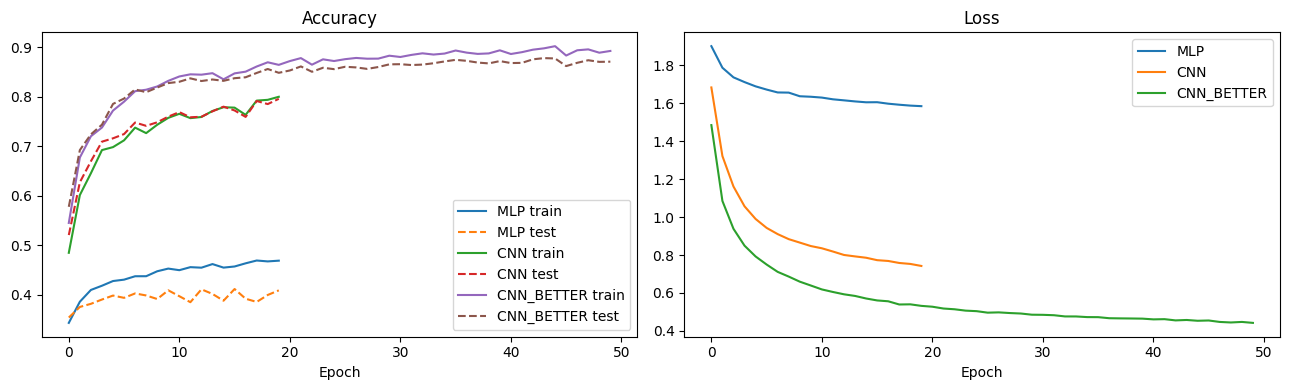

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, (tr_a, te_a, ls, _) in results.items():
    ax1.plot(tr_a, label=f"{name} train")
    ax1.plot(te_a, label=f"{name} test", linestyle="--")
    ax2.plot(ls, label=name)
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.set_title("Loss");     ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout(); plt.show()


### Accuracy + AUROC — modele standardowe

In [2]:
print(f'{"Model":<12} | {"Accuracy":>9} | {"AUROC":>7}')
print("-" * 34)
for name in ("MLP", "CNN", "CNN_BETTER"):
    print(name)
    m = load_model(name)
    probs, preds, labels = evaluate_full(m, testloader)
    acc   = accuracy_score(labels, preds)
    auroc = roc_auc_score(labels, probs, multi_class="ovr")
    print(f"{name:<12} | {acc:>9.2%} | {auroc:>7.2%}")


Model        |  Accuracy |   AUROC
----------------------------------
MLP


NameError: name 'load_model' is not defined

## 6. Adversarial Training

### Idea
Zamiast trenować na czystych obrazkach, w każdej epoce generujemy
adwersarialne przykłady metodą **PGD** i uczymy model je rozpoznawać.
Efekt: model jest odporny na ataki białej skrzynki (FGSM, PGD, CW, DeepFool).

### Parametry (standard CIFAR-10)
- `eps = 8/255` — maksymalne zniekształcenie (L∞)
- `alpha = eps/4` — krok PGD
- `iters = 7` — liczba kroków PGD


### Implementacja ataku PGD (używana do treningu i ewaluacji)

In [19]:
def generate_pgd_attack(model, images, labels, loss_fn,
                        eps=8/255, alpha=2/255, iters=7,
                        clip_min=-3.0, clip_max=3.0):
    """
    PGD L-infinity attack (Madry et al., 2018).

    clip_min/clip_max: zakres wartości pikseli po normalizacji.
    Domyślnie -3/3 – bezpiecznie pokrywa normalizację CIFAR-10.
    """
    images_adv = images.clone().detach()
    labels     = labels.to(images.device)

    # Losowy start w budżecie eps (silniejszy atak)
    images_adv = images_adv + torch.empty_like(images_adv).uniform_(-eps, eps)
    images_adv = torch.clamp(images_adv, clip_min, clip_max)

    # model.eval() – ważne przy BatchNorm, żeby nie psuć statystyk
    model.eval()

    for _ in range(iters):
        images_adv.requires_grad = True
        loss = loss_fn(model(images_adv), labels)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Krok FGSM
            images_adv = images_adv + alpha * images_adv.grad.sign()
            # Projekcja na kulę eps wokół oryginału
            eta        = torch.clamp(images_adv - images, -eps, eps)
            images_adv = torch.clamp(images + eta, clip_min, clip_max)

    return images_adv.detach()


### Pętla adversarial trainingu

In [20]:
def train_adversarial(model, optimizer, scheduler, loss_fn,
                      num_epochs=50, eps=8/255,
                      eval_robust_every=5,
                      train_loader=None, test_loader=None):
    """
    W każdej epoce:
    1. Generujemy adwersarialne obrazki (PGD)
    2. Trenujemy model na zepsutych obrazkach
    3. Co eval_robust_every epok mierzymy robust accuracy
    """
    if train_loader is None: train_loader = trainloader
    if test_loader  is None: test_loader  = testloader

    model = model.to(device)
    train_accs, test_accs, losses = [], [], []
    robust_log = {}  # {numer_epoki: robust_acc}

    for epoch in range(num_epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Generujemy adwersarialne przykłady
            adv = generate_pgd_attack(model, images, labels, loss_fn,
                                      eps=eps, alpha=eps/4, iters=7)

            # Trening na zepsutych obrazkach
            model.train()
            optimizer.zero_grad()
            loss = loss_fn(model(adv), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss  = running_loss / len(train_loader)
        train_acc = evaluate(model, train_loader)
        test_acc  = evaluate(model, test_loader)
        scheduler.step(avg_loss)
        lr = optimizer.param_groups[0]["lr"]

        rob_str = ""
        if (epoch + 1) % eval_robust_every == 0:
            rob = evaluate_robust(model, test_loader, loss_fn, eps=eps, n_batches=20)
            robust_log[epoch + 1] = rob
            rob_str = f" | robust: {rob:.2%}"

        print(f"Epoch {epoch+1:2d} | loss: {avg_loss:.4f} | "
              f"train: {train_acc:.2%} | test: {test_acc:.2%}"
              f"{rob_str} | lr: {lr:.2e}")

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(avg_loss)

    return train_accs, test_accs, losses, model, robust_log


### Trening CNN_ROBUST (50 epok)

In [41]:
model_robust = CnnBetter(dropout_p=0.3).to(device)
opt_r        = torch.optim.Adam(model_robust.parameters(), lr=1e-3, weight_decay=1e-4)
sched_r      = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_r, patience=3)
loss_fn_rob  = nn.CrossEntropyLoss(label_smoothing=0.1)

tr_a, te_a, ls, model_robust, robust_log = train_adversarial(
    model_robust, opt_r, sched_r, loss_fn_rob,
    num_epochs=50, eps=8/255, eval_robust_every=5,
    train_loader=trainloader, test_loader=testloader
)
results["CNN_ROBUST"] = (tr_a, te_a, ls, model_robust)

print("\n=== Robust accuracy co 5 epok ===")
for ep, acc in robust_log.items():
    print(f"  Epoch {ep:2d} | robust (PGD eps=8/255): {acc:.2%}")


Epoch  1 | loss: 1.9074 | train: 51.04% | test: 53.54% | lr: 1.00e-03
Epoch  2 | loss: 1.7084 | train: 60.05% | test: 62.65% | lr: 1.00e-03
Epoch  3 | loss: 1.6143 | train: 63.69% | test: 65.26% | lr: 1.00e-03
Epoch  4 | loss: 1.5542 | train: 68.32% | test: 69.53% | lr: 1.00e-03
Epoch  5 | loss: 1.5109 | train: 70.14% | test: 72.15% | robust: 59.30% | lr: 1.00e-03
Epoch  6 | loss: 1.4798 | train: 72.74% | test: 73.99% | lr: 1.00e-03
Epoch  7 | loss: 1.4550 | train: 72.83% | test: 73.83% | lr: 1.00e-03
Epoch  8 | loss: 1.4328 | train: 74.56% | test: 74.18% | lr: 1.00e-03
Epoch  9 | loss: 1.4162 | train: 74.24% | test: 74.90% | lr: 1.00e-03
Epoch 10 | loss: 1.4031 | train: 73.87% | test: 74.30% | robust: 61.17% | lr: 1.00e-03
Epoch 11 | loss: 1.3852 | train: 76.71% | test: 76.95% | lr: 1.00e-03
Epoch 12 | loss: 1.3718 | train: 78.37% | test: 77.92% | lr: 1.00e-03
Epoch 13 | loss: 1.3630 | train: 78.08% | test: 78.07% | lr: 1.00e-03
Epoch 14 | loss: 1.3543 | train: 78.02% | test: 78.08% |

In [ ]:
path = MODEL_REGISTRY["CNN_ROBUST"][2]
torch.save(results["CNN_ROBUST"][-1].state_dict(), path)
print(f"Saved {path}")


## 5.2 Trening CNN_ACC (100 epok, Mixup + CosineAnnealingLR)

In [21]:
model_acc = CnnAcc().to(device)
opt_acc   = torch.optim.Adam(model_acc.parameters(), lr=1e-3, weight_decay=1e-4)
sched_acc = torch.optim.lr_scheduler.CosineAnnealingLR(opt_acc, T_max=100, eta_min=1e-5)
loss_acc  = nn.CrossEntropyLoss(label_smoothing=0.1)

tr_a, te_a, ls, model_acc = train_acc(
    model_acc, opt_acc, sched_acc, loss_acc,
    num_epochs=100,
    mixup_alpha=0.4,
)
results["CNN_ACC"] = (tr_a, te_a, ls, model_acc)

Epoch  10 | loss: 1.3635 | train: 78.10% | test: 82.58% | lr: 9.76e-04
Epoch  15 | loss: 1.3011 | train: 84.24% | test: 86.70% | lr: 9.46e-04
Epoch  20 | loss: 1.2685 | train: 84.91% | test: 87.64% | lr: 9.05e-04
Epoch  25 | loss: 1.2349 | train: 86.29% | test: 88.80% | lr: 8.55e-04
Epoch  30 | loss: 1.2156 | train: 86.46% | test: 88.51% | lr: 7.96e-04
Epoch  35 | loss: 1.2070 | train: 89.66% | test: 90.46% | lr: 7.30e-04
Epoch  40 | loss: 1.1918 | train: 88.18% | test: 89.92% | lr: 6.58e-04
Epoch  45 | loss: 1.1854 | train: 89.82% | test: 90.71% | lr: 5.82e-04
Epoch  50 | loss: 1.1692 | train: 90.34% | test: 90.28% | lr: 5.05e-04
Epoch  55 | loss: 1.1517 | train: 91.85% | test: 91.65% | lr: 4.28e-04
Epoch  60 | loss: 1.1448 | train: 93.43% | test: 92.72% | lr: 3.52e-04
Epoch  65 | loss: 1.1209 | train: 93.90% | test: 92.64% | lr: 2.80e-04
Epoch  70 | loss: 1.1086 | train: 94.86% | test: 92.99% | lr: 2.14e-04
Epoch  75 | loss: 1.0954 | train: 95.37% | test: 93.41% | lr: 1.55e-04
Epoch 

In [22]:
torch.save(model_acc.state_dict(), "CNN_ACC_cifar10.pth")

## 7. Ewaluacja końcowa

Wszystkie ewaluacje wczytują wagi z plików `.pth` zapisanych zaraz po treningu.

Kolejność:
1. Tabela Accuracy / AUROC dla wszystkich modeli
2. Wykres clean vs robust accuracy (CNN_BETTER vs CNN_ROBUST)
3. Weryfikacja ładowania CNN_ROBUST


### Accuracy + AUROC — wszystkie modele

In [17]:
print(f'{"Model":<12} | {"Accuracy":>9} | {"AUROC":>7}')
print("-" * 34)
for name in MODEL_REGISTRY:
    try:
        m = load_model(name)
    except FileNotFoundError:
        print(f"{name:<12} | (brak pliku .pth — pomiń)")
        continue
    probs, preds, labels = evaluate_full(m, testloader)
    acc   = accuracy_score(labels, preds)
    auroc = roc_auc_score(labels, probs, multi_class="ovr")
    print(f"{name:<12} | {acc:>9.2%} | {auroc:>7.2%}")


Model        |  Accuracy |   AUROC
----------------------------------
MLP          |    40.88% |  83.77%
CNN          |    79.59% |  97.75%
CNN_BETTER   |    87.10% |  99.14%
CNN_ROBUST   |    81.54% |  98.22%
CNN_ACC      |    94.10% |  99.69%


### Clean vs Robust accuracy — CNN_BETTER vs CNN_ROBUST

Robust accuracy mierzona na **pełnym** test secie (n_batches=None) — kilka minut.


Model        |   Clean | Robust (PGD eps=8/255)
-----------------------------------------------
CNN_BETTER   |  87.10% |                 15.12%
CNN_ROBUST   |  81.54% |                 66.33%


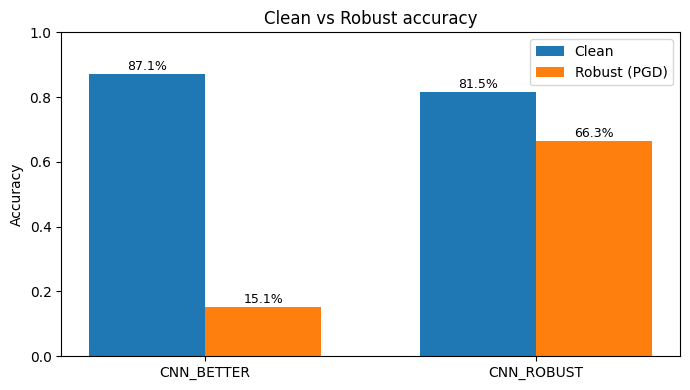

In [21]:
loss_fn_rob = nn.CrossEntropyLoss(label_smoothing=0.1)

compare = {
    "CNN_BETTER": (load_model("CNN_BETTER"), nn.CrossEntropyLoss()),
    "CNN_ROBUST": (load_model("CNN_ROBUST"), loss_fn_rob),
}

print(f'{"Model":<12} | {"Clean":>7} | {"Robust (PGD eps=8/255)":>22}')
print("-" * 47)
summary = {}
for name, (m, lfn) in compare.items():
    clean  = evaluate(m, testloader)
    robust = evaluate_robust(m, testloader, lfn, eps=8/255, n_batches=None)
    summary[name] = {"clean": clean, "robust": robust}
    print(f"{name:<12} | {clean:>7.2%} | {robust:>22.2%}")

# Wykres słupkowy
names  = list(summary)
x      = range(len(names))
w      = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar([i - w/2 for i in x], [summary[n]["clean"]  for n in names], w, label="Clean")
b2 = ax.bar([i + w/2 for i in x], [summary[n]["robust"] for n in names], w, label="Robust (PGD)")
ax.set_xticks(list(x)); ax.set_xticklabels(names)
ax.set_ylim(0, 1); ax.set_ylabel("Accuracy")
ax.set_title("Clean vs Robust accuracy")
ax.legend()
for bar in list(b1) + list(b2):
    ax.annotate(f"{bar.get_height():.1%}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


## 8. Ewaluacja końcowa — wczytywanie z pliku

Ta sekcja jest **niezależna od wcześniejszego treningu** — wczytuje zapisane wagi
i powtarza ewaluację. Uruchom ją po restarcie kernela (po wykonaniu sekcji 1–3).


In [1]:
import os

# --- definicja: nazwa → (klasa modelu, kwargs konstruktora, plik .pth) ---
MODEL_REGISTRY = {
    "MLP":        (MLP,       {"input_size": 3 * 32 * 32}, "MLP_cifar10.pth"),
    "CNN":        (CNN,       {},                           "CNN_cifar10.pth"),
    "CNN_BETTER": (CnnBetter, {},                           "CNN_BETTER_cifar10.pth"),
    "CNN_ROBUST": (CnnBetter, {},                           "CNN_ROBUST_cifar10.pth"),
    "CNN_ACC":    (CnnAcc,    {},                           "CNN_ACC_cifar10.pth"),
}

loaded_models = {}
for name, (ModelClass, kwargs, pth_file) in MODEL_REGISTRY.items():
    if not os.path.exists(pth_file):
        print(f"[SKIP] {pth_file} nie istnieje — pomijam {name}")
        continue
    m = ModelClass(**kwargs).to(device)
    m.load_state_dict(torch.load(pth_file, map_location=device))
    m.eval()
    loaded_models[name] = m
    print(f"[OK]   wczytano {pth_file}")

# --- Tabela Accuracy / AUROC ---
print(f'\n{"Model":<12} | {"Accuracy":>9} | {"AUROC":>7}')
print("-" * 34)
for name, m in loaded_models.items():
    probs, preds, labels = evaluate_full(m, testloader)
    acc   = accuracy_score(labels, preds)
    auroc = roc_auc_score(labels, probs, multi_class="ovr")
    print(f"{name:<12} | {acc:>9.2%} | {auroc:>7.2%}")


NameError: name 'MLP' is not defined

In [24]:
model_check = CnnBetter().to(device)
model_check.load_state_dict(torch.load("CNN_ROBUST_cifar10.pth", map_location=device))
model_check.eval()

imgs, _ = next(iter(testloader))
imgs = imgs.to(device)
with torch.no_grad():
    p_orig   = model_robust.predict(imgs).cpu()
    p_loaded = model_check.predict(imgs).cpu()

ok = (p_orig == p_loaded).all().item()
assert ok, "BLAD: predykcje roznia sie po zaladowaniu!"
print(f"Predykcje zgodne: {ok} — model zaladowany poprawnie.")


NameError: name 'model_robust' is not defined